# K means
**🧠 Unsupervised Learning: Introduction**

So far, we've studied supervised algorithms—models that learn from labeled data, meaning data with a known target variable (e.g., classification, regression).  
But in some cases, labels don't exist. We only have the data, and we want to discover hidden structure, patterns, or groupings.  
In such cases, we talk about **Unsupervised Machine Learning**.

**Use examples:**
- Customer segmentation (marketing)
- Grouping similar images
- Detecting anomalous behavior (fraud detection)
- Data compression or dimensionality reduction

**🔍 Unsupervised Learning: Clustering**

**Clustering** is an unsupervised learning technique that aims to automatically group observations into clusters such that:
- Elements within the same cluster are **similar**.
- Elements in different clusters are **dissimilar**.
Similarity is measured using a **distance metric**, such as:
- Euclidean distance
- Manhattan distance
- Cosine similarity

We let datas themself speak using a clustering algoritm.

**Unsupervised Learning: Clustering Algorithm Families**

Clustering algorithms can be grouped into different families based on their underlying approach:

| **Family**       | **Typical Algorithm**               | **Core Idea**                                                  |
|------------------|-------------------------------------|----------------------------------------------------------------|
| **Partitional**  | K-Means                             | Divides data into K groups by minimizing intra-cluster distance |
| **Hierarchical** | Agglomerative / Divisive Clustering | Builds a similarity tree (dendrogram)                          |
| **Density-Based**| DBSCAN                              | Identifies dense regions, ignores noise                        |
| **Model-Based**  | GMM (Gaussian Mixture Models)       | Assumes data comes from Gaussian distributions                 |

## K_Means Algorithm:

The k-means attemps to divide the data into **K predefined clusters** (an iperparameter) so that:
- Each point belongs to the cluster with the **nearest center (centroid)**.
- Points within the same cluster are as **similar** as possible.
- Points in different clusters are as **dissimilar** as possible.

⚙️ Algorithm Steps

1. **Initialization**  
   Randomly select **K initial centroids** from the dataset.
2. **Assignment**  
   Assign each data point to the **nearest centroid**, forming K clusters.
3. **Update**  
   Recalculate each centroid as the **mean of all points** assigned to its cluster.
4. **Repeat**  
   Iterate steps 2–3 until the centroids **no longer change** (convergence).


**✅ K-Means Clustering: Advantages and Limitations**

**🟢 Advantages**

- **Simple and fast**  
  K-Means is easy to implement and computationally efficient, especially on large datasets.
- **Scalable to large datasets**  
  Its time complexity is linear with respect to the number of data points, making it suitable for big data applications.
- **Interpretable results**  
  The output includes clear cluster assignments and centroid coordinates, which help interpret group characteristics and distances.
- **Works well with compact, spherical clusters**  
  When clusters are well-separated and roughly circular, K-Means performs very effectively.

**🔴 Limitations**

- **Requires predefining the number of clusters \( K \)**  
  Choosing the right value of \( K \) is non-trivial and often requires heuristics like the Elbow Method or Silhouette Score.
- **Assumes spherical cluster shapes**  
  K-Means struggles with clusters that are elongated, irregular, or vary in density.
- **Sensitive to outliers**  
  A single outlier can significantly shift a centroid, distorting the clustering result.
- **Converges to local minima**  
  The final clustering depends heavily on the initial centroid positions. Poor initialization can lead to suboptimal results.
> 💡 Tip: Use **K-Means++** to improve centroid initialization and reduce the risk of poor convergence.



**Load Dataset:**

In [8]:
import pandas as pd

# Load data
df = pd.read_csv("iris.csv", header=0)
X = df.drop("variety", axis= 1)
y = df["variety"]

**K_Means Model Creation**

| **Parameter** | **Meaning** |
|---------------|-------------|
| `n_clusters` (`K`) | Number of clusters to generate (must be specified by the user) |
| `init`        | Method for initializing centroids: `"random"` or `"k-means++"` |
| `max_iter`    | Maximum number of iterations allowed for convergence |
| `n_init`      | Number of times the algorithm runs with different centroid seeds (best result is chosen) |

> 💡 **K-Means++** improves stability by selecting initial centroids that are more spread out, reducing the risk of poor clustering due to bad initialization.


In [9]:
from sklearn.cluster import KMeans

# Apply K-Means
kmeans = KMeans(n_clusters=3, init="k-means++", n_init=10 , random_state=42)
y_pred = kmeans.fit_predict(x)

# Get the cluster labels assigned to each data point
lab = kmeans.labels_

# Get the coordinates of the cluster centroids
centers = kmeans.cluster_centers_

print(centers)


[[5.9016129  2.7483871  4.39354839 1.43387097]
 [5.006      3.428      1.462      0.246     ]
 [6.85       3.07368421 5.74210526 2.07105263]]


**Representation of Results**

[[5.9016129  2.7483871  4.39354839 1.43387097]
 [5.006      3.428      1.462      0.246     ]
 [6.85       3.07368421 5.74210526 2.07105263]]


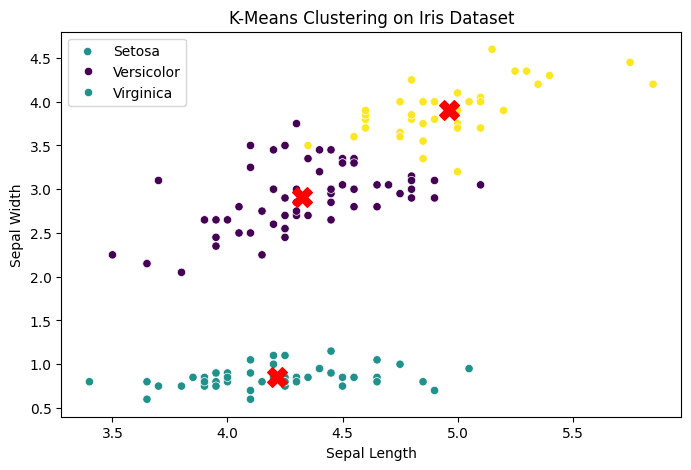

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# "sepal.length","sepal.width","petal.length","petal.width"

df['Cluster'] = y_kmeans
df_avg = pd.DataFrame({
    'avg_sl_sw': df[["sepal.length", "sepal.width"]].mean(axis=1),
    'avg_pl_pw': df[["petal.length", "petal.width"]].mean(axis=1)
})

centers_avg = pd.DataFrame({
    'avg_sl_sw': centers[:, [0, 1]].mean(axis=1),
    'avg_pl_pw': centers[:, [2, 3]].mean(axis=1)
})
print(centers)

plt.figure(figsize=(8, 5))
sns.scatterplot(x =df_avg["avg_sl_sw"], y=df_avg["avg_pl_pw"] , hue=df['Cluster'], palette='viridis')
plt.scatter(    centers_avg['avg_sl_sw'],    centers_avg['avg_pl_pw'],    c='red',    s=200,    marker='X', )

plt.title("K-Means Clustering on Iris Dataset")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.legend(y.unique())
plt.show()



**Finding The Best K for the Model "Elbow Rule"**

The Elbow Method helps determine the optimal number of clusters (*k*) for K-Means by measuring how tightly the data points are grouped around their centroids. It balances **model simplicity** with **clustering quality**.

**⚙️ How It Works**

1. Run K-Means for a range of *k* values (e.g., 1 to 10).
2. For each *k*, record the **inertia** — the sum of squared distances between each point and its assigned cluster center.
3. Plot *k* vs. inertia.
4. Look for the "elbow" point — where the rate of decrease sharply slows down.

**📉 Why It’s Called the “Elbow”**

The plot typically shows a steep drop in inertia for small *k*, followed by a gradual flattening. The point where this transition occurs resembles an **elbow** — indicating diminishing returns in clustering quality.


**📊 Interpretation**

- A small *k* may underfit: clusters are too broad.
- A large *k* may overfit: clusters are too specific.
- The **elbow point** offers a good trade-off between simplicity and performance.

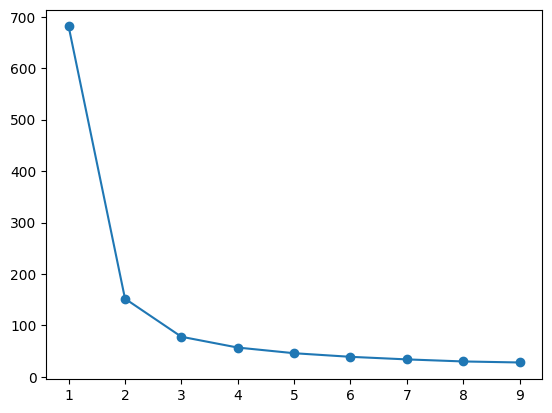

In [11]:
wcss = []

for n in range(1,10):
    kmeans = KMeans(n_clusters=n, init="k-means++", n_init=10 , random_state=42)
    kmeans.fit(x)
    wcss.append(int(kmeans.inertia_))

plt.plot([1,2,3,4,5,6,7,8,9], wcss, marker="o" )
    
plt.show()

### **Evaluating The Model**

# 📊 Clustering Evaluation: Internal vs External Metrics

When evaluating clustering results, we distinguish between:

## 🧠 Internal Metrics
These evaluate the **quality of the clustering structure** using only the input data and cluster assignments.  
They measure how **compact** and **well-separated** the clusters are.

### Common Internal Metrics:
- **Silhouette Score**: Combines cohesion and separation. Ranges from -1 to 1.
- **Davies-Bouldin Index**: Lower is better; measures average similarity between clusters.
- **Calinski-Harabasz Index**: Higher is better; ratio of between-cluster dispersion to within-cluster dispersion.

## 🏷️ External Metrics
These compare the clustering result to **ground truth labels**, if available.  
They measure how well the clustering matches known categories.

### Common External Metrics:
- **Adjusted Rand Index (ARI)**: Measures similarity between predicted and true labels. Adjusted for chance.
- **Normalized Mutual Information (NMI)**: Measures shared information between predicted and true labels.
- **Fowlkes-Mallows Index**: Geometric mean of precision and recall.

> ⚠️ External metrics require true labels, which are often unavailable in real-world unsupervised tasks.

**Evaluating the model:Internal Metrics**

In [12]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score


silhouette = silhouette_score(X, y_pred)
db_index = davies_bouldin_score(X, y_pred)
ch_index = calinski_harabasz_score(X, y_pred)

print(f"Silhouette Score          : {silhouette:.3f}  (range: -1 to 1, higher is better)")
print(f"Davies-Bouldin Index      : {db_index:.3f}  (lower is better)")
print(f"Calinski-Harabasz Index   : {ch_index:.3f}  (higher is better)")


🔍 Internal Clustering Evaluation Metrics
Silhouette Score          : 0.553  (range: -1 to 1, higher is better)
Davies-Bouldin Index      : 0.662  (lower is better)
Calinski-Harabasz Index   : 561.628  (higher is better)


**External Evaluation Metrics**

In [ ]:
# 📦 Import external clustering metrics
from sklearn.metrics import adjusted_rand_score, homogeneity_score, completeness_score


ari_sc = adjusted_rand_score(y, y_pred)
hom_sc = homogeneity_score(y, y_pred)
comp_sc = completeness_score(y, y_pred)

print(f"Adjusted Rand Index       : {ari_sc:.3f}  (adjusted for chance, higher is better)")
print(f"Homogeneity Score         : {hom_sc:.3f}  (each cluster contains only members of a single class)")
print(f"Completeness Score        : {comp_sc:.3f}  (all members of a class are assigned to the same cluster)")


In [ ]:
sil_samples = shiluette_score